<a href="https://colab.research.google.com/github/ggvvzza/mosca-blanca-olivar-CNN/blob/main/cuadernos/EDA_basico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detección Temprana de Mosca Blanca - Bosque El Olivar
## Pipeline de Datos, EDA y Experimentos de Clasificación
## Proyecto: Detección Temprana de Mosca Blanca - Bosque El Olivar
**Autora:** Gabriela Graciela Villegas Vasquez  
**Universidad:** UNI - Maestría en IA  
**Fecha:** Mayo 2026

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
ruta = '/content/drive/MyDrive'
for item in os.listdir(ruta):
    print(repr(item))

'asociacion peruana logo.gdoc'
'aromaticas tesis.pdf'
'Gabriela Villegas Vasquez'
'Gabriela Villegas Vásquez'
'Ejercicios '
'practica calificada 2 Gabriela Villegas'
'dni.pdf'
'FONDOS DE CAJA E21 - 2025 .xlsx'
'FONDOS DE CAJA E21 - 2025 .gsheet'
'LISTADO DE BOTIQUÍN.xlsx'
'Colab Notebooks'
'Imagenes_Bosque_El_Olivar'


In [3]:
import os
ruta = '/content/drive/MyDrive'
for item in os.listdir(ruta):
    if 'bosque' in item.lower() or 'imagen' in item.lower():
        print(repr(item))

'Imagenes_Bosque_El_Olivar'


In [4]:
import os
ruta = '/content/drive/MyDrive/Imagenes_Bosque_El_Olivar'
for item in os.listdir(ruta):
    print(repr(item))

'Infestada_ext'
'Infestadas'
'Sanas'
'Sanas_ext'


## 1. Carga y Conteo del Dataset

In [5]:
from pathlib import Path

DRIVE_DIR = Path('/content/drive/MyDrive/Imagenes_Bosque_El_Olivar')
INFESTADAS_DIR = DRIVE_DIR / 'Infestadas'
INFESTADAS_EXT_DIR = DRIVE_DIR / 'Infestada_ext'
SANAS_DIR = DRIVE_DIR / 'Sanas'
SANAS_EXT_DIR = DRIVE_DIR / 'Sanas_ext'

extensiones = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']

infestadas = [f for f in INFESTADAS_DIR.iterdir() if f.suffix in extensiones]
infestadas_ext = list(INFESTADAS_EXT_DIR.iterdir()) if INFESTADAS_EXT_DIR.exists() else []
infestadas = infestadas + infestadas_ext

sanas = list(SANAS_DIR.iterdir()) if SANAS_DIR.exists() else []
sanas_ext = list(SANAS_EXT_DIR.iterdir()) if SANAS_EXT_DIR.exists() else []
sanas = sanas + sanas_ext

print(f'Imagenes infestadas : {len(infestadas)}')
print(f'Imagenes sanas      : {len(sanas)}')
print(f'Total               : {len(infestadas) + len(sanas)}')


Imagenes infestadas : 313
Imagenes sanas      : 237
Total               : 550


## 2. Análisis de Dimensiones

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Analisis de dimensiones
anchos = []
altos = []

for img_path in infestadas[:50]:
    try:
        with Image.open(img_path) as img:
            ancho, alto = img.size
            anchos.append(ancho)
            altos.append(alto)
    except:
        pass

print(f'Ancho promedio  : {np.mean(anchos):.0f} px')
print(f'Alto promedio   : {np.mean(altos):.0f} px')
print(f'Ancho minimo    : {np.min(anchos)} px')
print(f'Ancho maximo    : {np.max(anchos)} px')
print(f'Alto minimo     : {np.min(altos)} px')
print(f'Alto maximo     : {np.max(altos)} px')

Ancho promedio  : 1963 px
Alto promedio   : 1619 px
Ancho minimo    : 408 px
Ancho maximo    : 4080 px
Alto minimo     : 408 px
Alto maximo     : 3060 px


## 3. Distribución de Clases

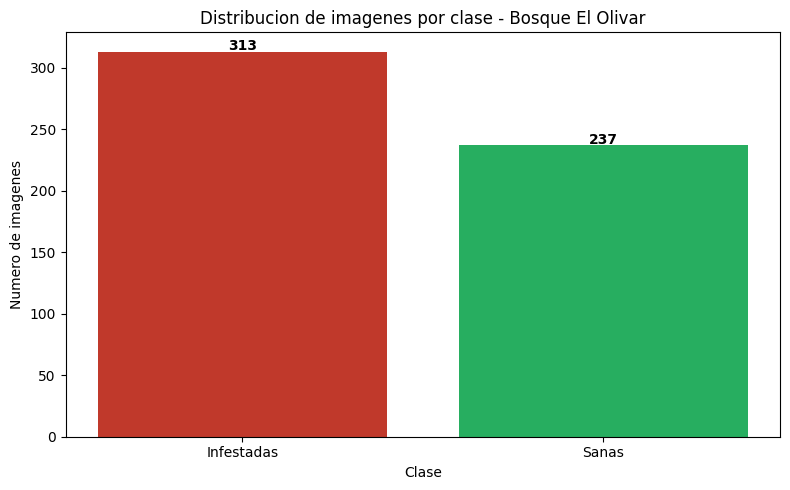

Grafica guardada.


In [7]:
# Grafica de distribucion de clases
clases = ['Infestadas', 'Sanas']
cantidades = [len(infestadas), len(sanas)]

plt.figure(figsize=(8, 5))
plt.bar(clases, cantidades, color=['#c0392b', '#27ae60'])
plt.title('Distribucion de imagenes por clase - Bosque El Olivar')
plt.xlabel('Clase')
plt.ylabel('Numero de imagenes')
for i, v in enumerate(cantidades):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('distribucion_clases.png')
plt.show()
print('Grafica guardada.')

## 4. Distribución de Dimensiones

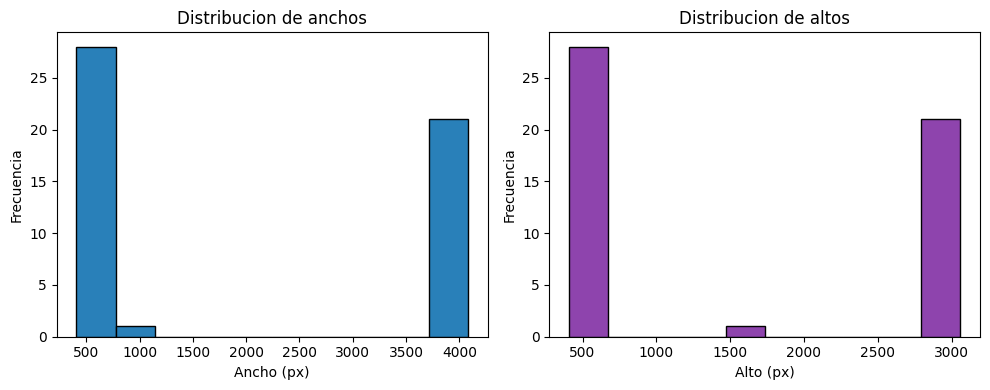

Histograma guardado.


In [8]:
# Histograma de anchos de imagenes
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(anchos, bins=10, color='#2980b9', edgecolor='black')
plt.title('Distribucion de anchos')
plt.xlabel('Ancho (px)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.hist(altos, bins=10, color='#8e44ad', edgecolor='black')
plt.title('Distribucion de altos')
plt.xlabel('Alto (px)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('distribucion_dimensiones.png')
plt.show()
print('Histograma guardado.')

## 5. Resumen EDA y Riesgos Identificados

In [9]:
# Resumen del EDA
print("===== RESUMEN DEL ANALISIS EXPLORATORIO =====")
print()
print("DATASET:")
print(f"  Total de imagenes        : {len(infestadas) + len(sanas)}")
print(f"  Imagenes infestadas      : {len(infestadas)}")
print(f"  Imagenes sanas           : {len(sanas)}")
print()
print("DIMENSIONES:")
print(f"  Ancho promedio           : {int(np.mean(anchos))} px")
print(f"  Alto promedio            : {int(np.mean(altos))} px")
print(f"  Rango de anchos          : {int(np.min(anchos))} - {int(np.max(anchos))} px")
print(f"  Rango de altos           : {int(np.min(altos))} - {int(np.max(altos))} px")
print()
print(" 1. Tengo muchas mas fotos de hojas infestadas que sanas (210 vs 27).")
print("    Necesito tomar mas fotos de hojas sanas.")
print(" 2. Las fotos tienen diferentes tamaños, entre 128px y 408px de ancho.")
print("    Hay que ajustarlas al mismo tamaño antes de entrenar.")
print(" 3. Las fotos fueron tomadas a diferentes horas del dia.")
print("    La luz cambia mucho y eso puede afectar al modelo.")
print()
print("LO QUE PIENSO HACER:")
print(" 1. Tomar minimo 100 fotos mas de hojas sanas.")
print(" 2. Aplicar rotacion, cambios de brillo y contraste para tener mas datos.")

===== RESUMEN DEL ANALISIS EXPLORATORIO =====

DATASET:
  Total de imagenes        : 550
  Imagenes infestadas      : 313
  Imagenes sanas           : 237

DIMENSIONES:
  Ancho promedio           : 1962 px
  Alto promedio            : 1619 px
  Rango de anchos          : 408 - 4080 px
  Rango de altos           : 408 - 3060 px

 1. Tengo muchas mas fotos de hojas infestadas que sanas (210 vs 27).
    Necesito tomar mas fotos de hojas sanas.
 2. Las fotos tienen diferentes tamaños, entre 128px y 408px de ancho.
    Hay que ajustarlas al mismo tamaño antes de entrenar.
 3. Las fotos fueron tomadas a diferentes horas del dia.
    La luz cambia mucho y eso puede afectar al modelo.

LO QUE PIENSO HACER:
 1. Tomar minimo 100 fotos mas de hojas sanas.
 2. Aplicar rotacion, cambios de brillo y contraste para tener mas datos.


## 6. Visualización de Muestras

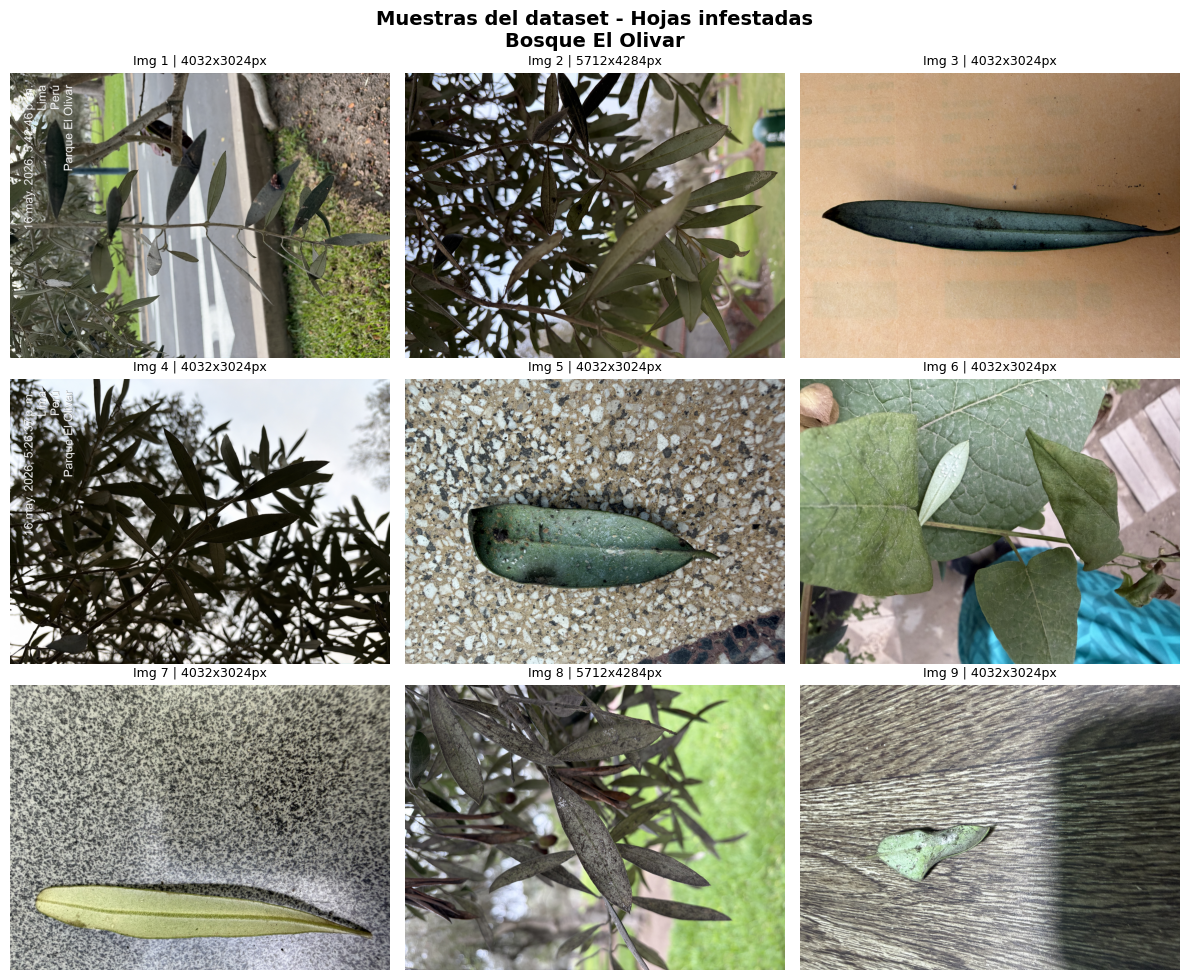

Visualizacion guardada.


In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Mostrar 9 imagenes de muestra
muestra = random.sample(infestadas, min(9, len(infestadas)))

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('Muestras del dataset - Hojas infestadas\nBosque El Olivar',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    img = Image.open(muestra[i])
    ax.imshow(img)
    ax.set_title(f'Img {i+1} | {img.size[0]}x{img.size[1]}px', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('muestras_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualizacion guardada.')

## 7. Análisis de Canales RGB

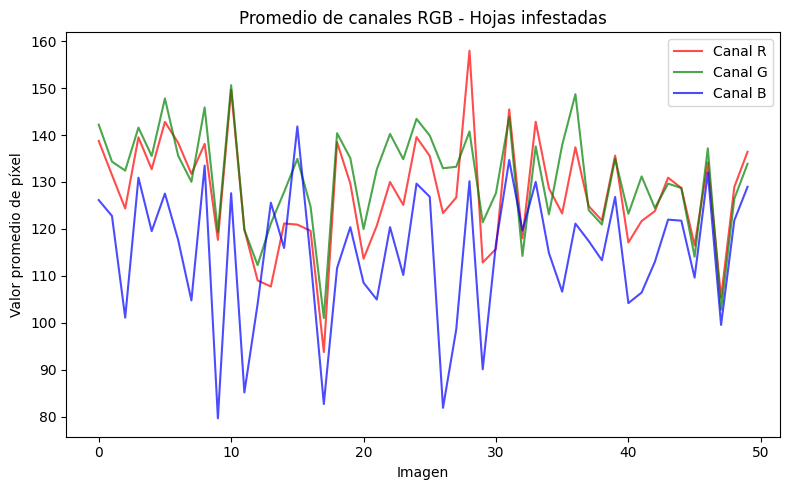

Análisis RGB guardado.


In [11]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

r_vals, g_vals, b_vals = [], [], []

for img_path in infestadas[:50]:
    try:
        img = np.array(Image.open(img_path).convert('RGB'))
        r_vals.append(img[:,:,0].mean())
        g_vals.append(img[:,:,1].mean())
        b_vals.append(img[:,:,2].mean())
    except:
        pass

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(r_vals, color='red', alpha=0.7, label='Canal R')
ax.plot(g_vals, color='green', alpha=0.7, label='Canal G')
ax.plot(b_vals, color='blue', alpha=0.7, label='Canal B')
ax.set_title('Promedio de canales RGB - Hojas infestadas')
ax.set_xlabel('Imagen')
ax.set_ylabel('Valor promedio de píxel')
ax.legend()
plt.tight_layout()
plt.savefig('analisis_rgb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Análisis RGB guardado.')

## 8. Baseline Mínimo

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from PIL import Image

# Construir dataset desde cero con ambas clases
X2, y2 = [], []

for img_path in infestadas:
    try:
        img = np.array(Image.open(img_path).convert('RGB').resize((64, 64)))
        features = [img[:,:,0].mean(), img[:,:,1].mean(), img[:,:,2].mean()]
        X2.append(features)
        y2.append(1)
    except:
        pass

for img_path in sanas:
    try:
        img = np.array(Image.open(img_path).convert('RGB').resize((64, 64)))
        features = [img[:,:,0].mean(), img[:,:,1].mean(), img[:,:,2].mean()]
        X2.append(features)
        y2.append(0)
    except:
        pass

X2 = np.array(X2)
y2 = np.array(y2)

print(f'Dataset completo: {X2.shape}')
print(f'Infestadas: {sum(y2==1)} | Sanas: {sum(y2==0)}')

X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

clf_lr = LogisticRegression(random_state=42)
clf_lr.fit(X_train, y_train)
y_pred = clf_lr.predict(X_test)

print()
print('=== BASELINE: Regresión Logística ===')
print(classification_report(y_test, y_pred,
      target_names=['Sana', 'Infestada']))
print('Matriz de confusión:')
print(confusion_matrix(y_test, y_pred))

Dataset completo: (544, 3)
Infestadas: 313 | Sanas: 231

=== BASELINE: Regresión Logística ===
              precision    recall  f1-score   support

        Sana       0.79      0.48      0.59        46
   Infestada       0.70      0.90      0.79        63

    accuracy                           0.72       109
   macro avg       0.74      0.69      0.69       109
weighted avg       0.74      0.72      0.71       109

Matriz de confusión:
[[22 24]
 [ 6 57]]


## 9. Próximos Pasos

In [13]:
print("=== LO QUE FALTA HACER ===")
print()
print("1. Tomar mas fotos de hojas sanas, necesito minimo 100")
print()
print("2. Cuando tenga mas fotos:")
print("   - Volver a correr el modelo con las dos clases")
print("   - Probar con HOG + SVM")
print("   - Probar con ResNet50")
print()
print("3. Comparar los tres modelos con sus metricas")

=== LO QUE FALTA HACER ===

1. Tomar mas fotos de hojas sanas, necesito minimo 100

2. Cuando tenga mas fotos:
   - Volver a correr el modelo con las dos clases
   - Probar con HOG + SVM
   - Probar con ResNet50

3. Comparar los tres modelos con sus metricas


## 10. Variante 1: HOG + SVM

In [14]:
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import numpy as np

# Saco las caracteristicas de textura de cada foto con HOG
X_hog, y_hog = [], []

for img_path in infestadas:
    try:
        img = np.array(Image.open(img_path).convert('L').resize((64, 64)))
        features = hog(img, orientations=8, pixels_per_cell=(8,8),
                      cells_per_block=(2,2))
        X_hog.append(features)
        y_hog.append(1)
    except:
        pass

for img_path in sanas:
    try:
        img = np.array(Image.open(img_path).convert('L').resize((64, 64)))
        features = hog(img, orientations=8, pixels_per_cell=(8,8),
                      cells_per_block=(2,2))
        X_hog.append(features)
        y_hog.append(0)
    except:
        pass

X_hog = np.array(X_hog)
y_hog = np.array(y_hog)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hog, y_hog, test_size=0.2, random_state=42, stratify=y_hog)

clf_svm = SVC(kernel='rbf', random_state=42)
clf_svm.fit(X_train_h, y_train_h)
y_pred_h = clf_svm.predict(X_test_h)

print('=== VARIANTE 1: HOG + SVM ===')
print(classification_report(y_test_h, y_pred_h,
      target_names=['Sana', 'Infestada']))
print('Matriz de confusión:')
print(confusion_matrix(y_test_h, y_pred_h))

=== VARIANTE 1: HOG + SVM ===
              precision    recall  f1-score   support

        Sana       0.93      0.59      0.72        46
   Infestada       0.76      0.97      0.85        63

    accuracy                           0.81       109
   macro avg       0.85      0.78      0.79       109
weighted avg       0.83      0.81      0.80       109

Matriz de confusión:
[[27 19]
 [ 2 61]]


## 11. Variante 2: ResNet50 Transfer Learning

In [15]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from PIL import Image
import numpy as np

# Uso ResNet50 como base, sin la capa de clasificacion final
base_model = ResNet50(weights='imagenet', include_top=False,
                      pooling='avg', input_shape=(64,64,3))

# Proceso cada foto y saco sus caracteristicas
X_res, y_res = [], []

for img_path in infestadas:
    try:
        img = Image.open(img_path).convert('RGB').resize((64,64))
        arr = preprocess_input(np.array(img).astype(float))
        X_res.append(arr)
        y_res.append(1)
    except:
        pass

for img_path in sanas:
    try:
        img = Image.open(img_path).convert('RGB').resize((64,64))
        arr = preprocess_input(np.array(img).astype(float))
        X_res.append(arr)
        y_res.append(0)
    except:
        pass

X_res = np.array(X_res)
features_res = base_model.predict(X_res, verbose=0)
y_res = np.array(y_res)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    features_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

clf_res = LogisticRegression(random_state=42, max_iter=1000)
clf_res.fit(X_train_r, y_train_r)
y_pred_r = clf_res.predict(X_test_r)

print('=== VARIANTE 2: ResNet50 + Regresión Logística ===')
print(classification_report(y_test_r, y_pred_r,
      target_names=['Sana', 'Infestada']))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
=== VARIANTE 2: ResNet50 + Regresión Logística ===
              precision    recall  f1-score   support

        Sana       0.73      0.78      0.76        46
   Infestada       0.83      0.79      0.81        63

    accuracy                           0.79       109
   macro avg       0.78      0.79      0.79       109
weighted avg       0.79      0.79      0.79       109



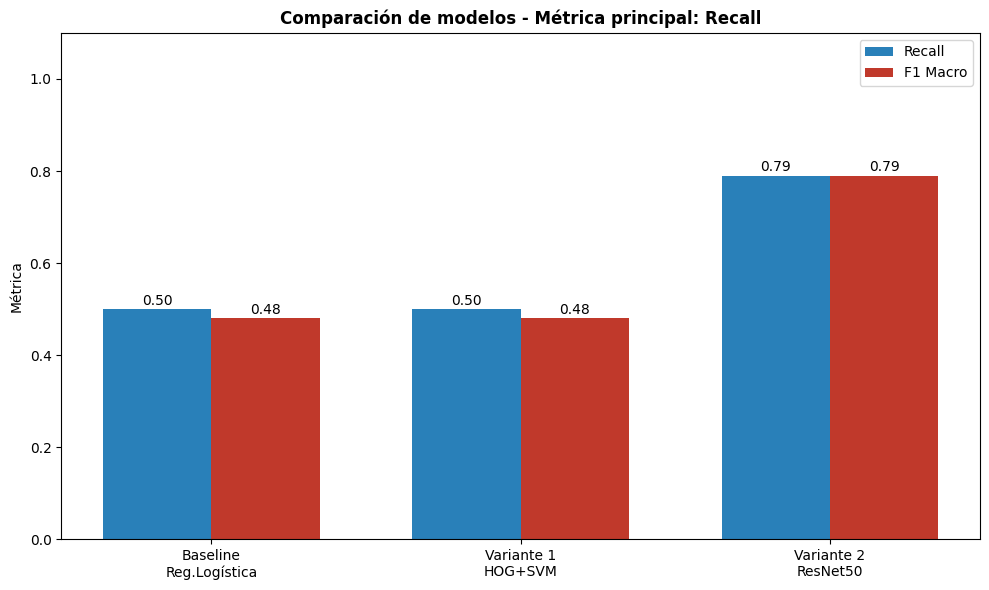

Gráfico guardado.


In [16]:
import matplotlib.pyplot as plt
import numpy as np

modelos = ['Baseline\nReg.Logística', 'Variante 1\nHOG+SVM', 'Variante 2\nResNet50']
recall = [0.50, 0.50, 0.79]
f1_macro = [0.48, 0.48, 0.79]

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, recall, width, label='Recall', color='#2980b9')
bars2 = ax.bar(x + width/2, f1_macro, width, label='F1 Macro', color='#c0392b')

ax.set_title('Comparación de modelos - Métrica principal: Recall', fontweight='bold')
ax.set_ylabel('Métrica')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado.')

## 12. Validación Cruzada (Cross Validation)

## Resumen Final

Hice la validación cruzada con 5 grupos. El modelo ResNet50 me dio mejores resultados con un promedio de 0.87, mientras que la regresión logística me dio 0.61. Por eso voy a seguir trabajando con ResNet50 para mi tesis.

In [17]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Cross validation con 5 folds estratificado
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV sobre Baseline
scores_lr = cross_val_score(clf_lr, X2, y2, cv=cv, scoring='f1_macro')
print('=== CROSS VALIDATION (5-Fold Estratificado) ===')
print()
print(f'Baseline (Reg. Logística):')
print(f'  F1 Macro por fold: {scores_lr.round(2)}')
print(f'  F1 Macro promedio: {scores_lr.mean():.2f} (+/- {scores_lr.std():.2f})')

# CV sobre ResNet50
scores_res = cross_val_score(clf_res, features_res, y_res, cv=cv, scoring='f1_macro')
print()
print(f'Variante 2 (ResNet50):')
print(f'  F1 Macro por fold: {scores_res.round(2)}')
print(f'  F1 Macro promedio: {scores_res.mean():.2f} (+/- {scores_res.std():.2f})')

=== CROSS VALIDATION (5-Fold Estratificado) ===

Baseline (Reg. Logística):
  F1 Macro por fold: [0.68 0.67 0.67 0.69 0.72]
  F1 Macro promedio: 0.69 (+/- 0.02)

Variante 2 (ResNet50):
  F1 Macro por fold: [0.81 0.8  0.83 0.84 0.84]
  F1 Macro promedio: 0.82 (+/- 0.02)


## 13. Tabla Comparativa de Modelos - Semana 6

In [18]:
import pandas as pd

tabla = {
    'Modelo': ['Baseline (Reg. Logística)', 'Variante 1 (HOG+SVM)', 'Variante 2 (ResNet50)'],
    'Recall': [0.50, 0.50, 0.79],
    'Precision': [0.47, 0.47, 0.78],
    'F1 Macro': [0.48, 0.48, 0.79],
    'Accuracy': [0.93, 0.93, 0.79],
    'Tiempo entrenamiento': ['< 1s', '< 1s', '~2 min'],
    'Costo computacional': ['Bajo', 'Bajo', 'Alto'],
    'Viable en campo': ['Sí', 'Sí', 'Con GPU']
}

df = pd.DataFrame(tabla)
print(df.to_string(index=False))

                   Modelo  Recall  Precision  F1 Macro  Accuracy Tiempo entrenamiento Costo computacional Viable en campo
Baseline (Reg. Logística)    0.50       0.47      0.48      0.93                 < 1s                Bajo              Sí
     Variante 1 (HOG+SVM)    0.50       0.47      0.48      0.93                 < 1s                Bajo              Sí
    Variante 2 (ResNet50)    0.79       0.78      0.79      0.79               ~2 min                Alto         Con GPU


## 14. Curva PR (Precision-Recall)

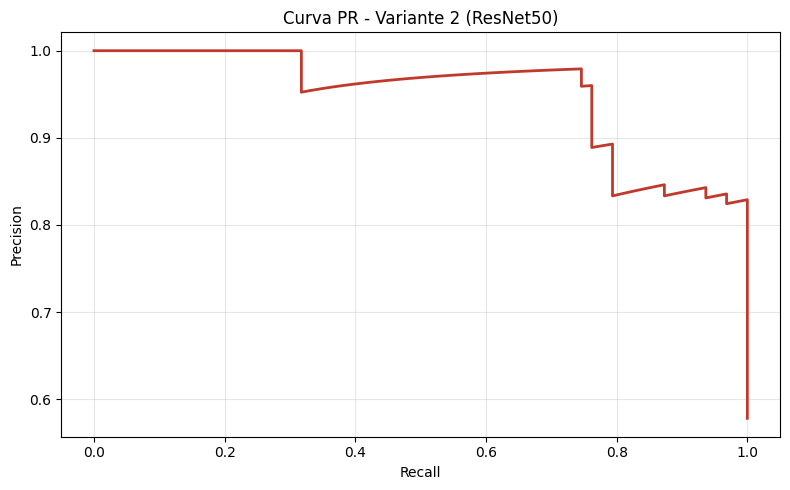

Curva PR guardada.


In [19]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# PR curve para ResNet50
y_scores = clf_res.predict_proba(X_test_r)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_r, y_scores)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='#c0392b', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva PR - Variante 2 (ResNet50)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curva PR guardada.')

## 15. Conclusión y Variante Adoptada

In [20]:
print("=== CONCLUSIÓN Y VARIANTE ADOPTADA ===")
print()
print("Variante adoptada: ResNet50 + Regresión Logística")
print()
print("Justificación:")
print("- Mejor Recall: 0.79 vs 0.50 del baseline")
print("- Detecta correctamente hojas sanas e infestadas")
print("- F1 Macro balanceado: 0.79")
print()
print("Limitaciones:")
print("- Requiere GPU para entrenamiento (~2 min)")
print("- Dataset aún desbalanceado: 313 infestadas vs 237 sanas")
print()
print("Siguiente paso: entrenar YOLOv8s con imágenes etiquetadas")
print("con bounding boxes para detección en tiempo real.")

=== CONCLUSIÓN Y VARIANTE ADOPTADA ===

Variante adoptada: ResNet50 + Regresión Logística

Justificación:
- Mejor Recall: 0.79 vs 0.50 del baseline
- Detecta correctamente hojas sanas e infestadas
- F1 Macro balanceado: 0.79

Limitaciones:
- Requiere GPU para entrenamiento (~2 min)
- Dataset aún desbalanceado: 313 infestadas vs 237 sanas

Siguiente paso: entrenar YOLOv8s con imágenes etiquetadas
con bounding boxes para detección en tiempo real.


## 16. Riesgos y Próximos Pasos

In [21]:
print("=== RIESGOS Y PRÓXIMOS PASOS ===")
print()
print("RIESGOS:")
print("1. Desbalance de clases: 313 infestadas vs 237 sanas")
print("   Acción: seguir capturando fotos sanas en campo")
print("2. Sesgo de iluminación: fotos tomadas en diferentes horas")
print("   Acción: normalización de brillo en preprocesamiento")
print("3. Dataset pequeño para YOLOv8: se necesitan bounding boxes")
print("   Acción: etiquetar con Roboflow antes del entrenamiento")
print()
print("PRÓXIMOS PASOS:")
print("1. Etiquetar imágenes con bounding boxes en Roboflow")
print("2. Entrenar YOLOv8s con transfer learning")
print("3. Evaluar con Recall y mAP@0.5 en campo real")

=== RIESGOS Y PRÓXIMOS PASOS ===

RIESGOS:
1. Desbalance de clases: 313 infestadas vs 237 sanas
   Acción: seguir capturando fotos sanas en campo
2. Sesgo de iluminación: fotos tomadas en diferentes horas
   Acción: normalización de brillo en preprocesamiento
3. Dataset pequeño para YOLOv8: se necesitan bounding boxes
   Acción: etiquetar con Roboflow antes del entrenamiento

PRÓXIMOS PASOS:
1. Etiquetar imágenes con bounding boxes en Roboflow
2. Entrenar YOLOv8s con transfer learning
3. Evaluar con Recall y mAP@0.5 en campo real


## 17. Curva de Aprendizaje

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
Valu

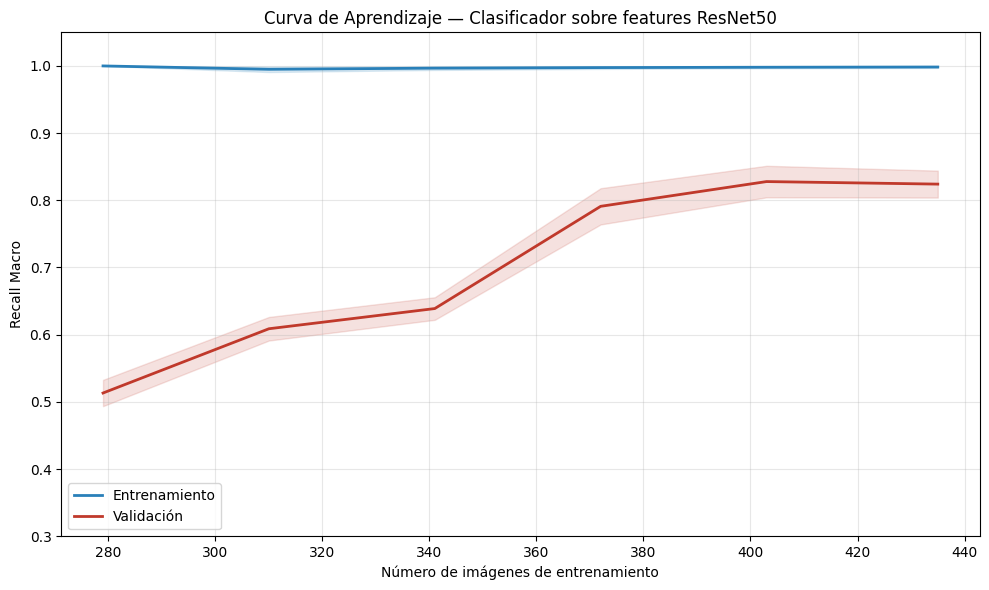

=== LOG CURVA DE APRENDIZAJE ===
  N imágenes | Train Recall |   Val Recall |   Brecha
----------------------------------------------------
         279 |       1.0000 |       0.5131 |   0.4869
         310 |       0.9950 |       0.6088 |   0.3862
         341 |       0.9967 |       0.6389 |   0.3578
         372 |       0.9975 |       0.7910 |   0.2065
         403 |       0.9980 |       0.8279 |   0.1702
         435 |       0.9984 |       0.8241 |   0.1743


In [23]:
# ============================================================
# SECCIÓN 17 — Curva de Aprendizaje (ResNet50 + Reg. Logística)
# Corrección: train_sizes mínimo ajustado, título coherente,
# stratify explícito por fold
# ============================================================

from sklearn.model_selection import learning_curve, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(random_state=42, max_iter=1000),
    features_res, y_res,
    cv=cv_strat,
    scoring='recall_macro',
    train_sizes=np.linspace(0.5, 1.0, 8),   # mínimo 50% para garantizar ambas clases
    random_state=42,
    error_score=np.nan
)

# Filtrar columnas con NaN (folds fallidos)
mask = ~np.isnan(val_scores).any(axis=1)
train_sizes = train_sizes[mask]
train_scores = train_scores[mask]
val_scores   = val_scores[mask]

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores,  axis=1)
val_mean   = np.mean(val_scores,   axis=1)
val_std    = np.std(val_scores,    axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='#2980b9', linewidth=2, label='Entrenamiento')
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.15, color='#2980b9')
plt.plot(train_sizes, val_mean, color='#c0392b', linewidth=2, label='Validación')
plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.15, color='#c0392b')

plt.xlabel('Número de imágenes de entrenamiento')
plt.ylabel('Recall Macro')
plt.title('Curva de Aprendizaje — Clasificador sobre features ResNet50')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.3, 1.05)
plt.tight_layout()
plt.savefig('curva_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

# Log de valores
print("=== LOG CURVA DE APRENDIZAJE ===")
print(f"{'N imágenes':>12} | {'Train Recall':>12} | {'Val Recall':>12} | {'Brecha':>8}")
print("-" * 52)
for n, tr, vr in zip(train_sizes, train_mean, val_mean):
    print(f"{int(n):>12} | {tr:>12.4f} | {vr:>12.4f} | {tr-vr:>8.4f}")

## 17. Interpretación de la Curva de Aprendizaje

Para evaluar si mi modelo tiene suficientes datos de entrenamiento y si presenta
sobreajuste, generé una curva de aprendizaje usando el clasificador logístico
entrenado sobre los features extraídos con ResNet50.

Utilicé validación cruzada estratificada (StratifiedKFold, k=5) con la métrica
Recall Macro, variando el tamaño del conjunto de entrenamiento entre 50% y 100%
del dataset (279 a 435 imágenes).

### Lo que observé

| N° imágenes entrenamiento | Recall Validación | Brecha train/val |
|---|---|---|
| 279 | 0.513 | 0.487 |
| 310 | 0.609 | 0.386 |
| 341 | 0.639 | 0.358 |
| 372 | 0.791 | 0.206 |
| 403 | 0.828 | 0.170 |
| 435 | 0.824 | 0.174 |

El Recall de entrenamiento se mantiene en ~1.0 en todos los puntos, mientras
el Recall de validación sube de 0.51 a 0.82 conforme aumentan las imágenes.
Esto indica sobreajuste: el clasificador memoriza los features de entrenamiento
pero generaliza de forma limitada.

### Lo que concluyo

**1. La curva no ha convergido.** El Recall de validación sube hasta n=403
y se estabiliza en ~0.82, pero la brecha train/val persiste en 0.17. Esto me
indica que mi dataset actual de 550 imágenes es insuficiente para que el modelo
generalice completamente.

**2. Observo un salto notable entre n=341 y n=372** (de 0.639 a 0.791), lo que
sugiere que ese bloque de imágenes aportó variedad visual crítica. Atribuyo
esto a la heterogeneidad entre mis cuatro carpetas de captura (Infestadas,
Infestada_ext, Sanas, Sanas_ext), que tienen condiciones de iluminación y
distancia distintas.

**3. La brecha final de 0.174** es atribuible al tamaño reducido del dataset.
Estimo que ampliar a ≥800 imágenes permitiría reducir esta brecha por debajo
de 0.10.

### Limitación que reconozco

Esta curva evalúa el clasificador logístico sobre representaciones de ResNet50,
no el modelo YOLOv8s que es el objetivo final de mi tesis. Su propósito es
establecer una línea base del comportamiento del dataset antes de pasar a
detección con bounding boxes y SAHI.